# Домашнее задание: Построение RAG-системы с трансформерными декодерами

В этом домашнем задании вы закрепите знания о трансформерных декодерах и архитектуре с (RAG). Мы пройдем путь от простого полнотекстового поиска до продвинутого пайплайна с переранжированием и использованием LLM для генерации ответа.

## Практический бизнес-кейс: "ВикиПомощник" для контент-агентства

Крупное контент-агентство ежедневно создает сотни экспертных статей, аналитических отчетов и образовательных материалов. Редакторы агентства постоянно работают с огромным объемом энциклопедической информации. Сейчас процесс проверки фактов и поиска нужных деталей в справочниках занимает у них до 30% рабочего времени. Ручной поиск неэффективен, а использование публичных LLM без контекста часто приводит к галлюцинациям в статьях.

Руководство агентства поставило задачу разработать внутренний инструмент "ВикиПомощник". Это RAG-система, которая должна принимать вопрос редактора, мгновенно находить наиболее релевантные абзацы в проверенной базе знаний (русскоязычной Википедии) и формировать точный, лаконичный ответ на основе найденного контекста.

Ожидаемый результат внедрения ML-решения — сокращение времени на фактчекинг в 3 раза и полное устранение фактологических ошибок в выпускаемых материалах за счет опоры на доверенные источники.

## Рекомендации по выполнению в Google Colab

Для выполнения заданий, связанных с нейросетевыми моделями (BGE-M3, BGE-Reranker, Qwen3.5-9B), настоятельно рекомендуется использовать GPU.
1. В верхнем меню выберите `Среда выполнения` -> `Сменить среду выполнения`.
2. В поле `Аппаратный ускоритель` выберите `T4 GPU`.

**Решение проблемы нехватки памяти (CUDA Out of Memory):**
Если вы столкнулись с ошибкой `CUDA out of memory`, попробуйте следующие шаги:
- Уменьшите размер батча (например, с 32 до 16 или 8) при получении эмбеддингов.
- Ограничьте максимальную длину последовательности токенов (`max_length`).
- Перезапустите среду выполнения (`Среда выполнения` -> `Перезапустить среду выполнения`).
- В коде можно использовать принудительную очистку кэша:
```python
import torch
import gc
torch.cuda.empty_cache()
gc.collect()
```

Не забудьте сохранить копию ноутбука на свой Google Drive перед началом работы (`Файл` -> `Сохранить копию на Google Диск`).

## Таблица распределения баллов

| Блок | Задание | Баллы |
|---|---|---|
| **Часть 1. Стандартное ДЗ** | | **50** |
| 1 | Загрузка и подготовка данных (SberQuAD) | 8 |
| 2 | Полнотекстовый поиск (BM25) | 10 |
| 3 | Семантический поиск (BGE-M3) | 12 |
| 4 | Оценка качества: BM25 vs Семантика | 8 |
| 5 | RAG с декодером (Qwen3.5-9B) | 7 |
| 6 | Оценка стоимости запросов | 5 |
| **Часть 2. Продвинутое ДЗ** | | **50** |
| 7 | Гибридный поиск (RRF) | 10 |
| 8 | Переранжирование (Cross-Encoder) | 12 |
| 9 | Полный пайплайн с переранжированием и LLM | 8 |
| 10 | Сравнительный анализ всех стратегий и замер скорости | 10 |
| 11 | Расширенная оценка стоимости запросов | 5 |
| 12 | Итоговые выводы | 5 |
| **Итого** | | **100** |


In [2]:
# Установка необходимых библиотек
!pip install -q datasets sentence-transformers faiss-cpu rank_bm25 openai tiktoken pandas matplotlib seaborn faiss-gpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 MB 7.2 MB/s eta 0:00:00


## Блок 0: Формализация задачи

Прежде чем писать код, давайте формализуем нашу бизнес-задачу в терминах машинного обучения.
Бизнес-задача: Автоматизировать поиск фактов в базе знаний и формирование ответов на вопросы редакторов.
ML-задача: Построение пайплайна информационного поиска (Information Retrieval) и генерации текста (Text Generation).

Для оценки качества поиска мы будем использовать две метрики:
1. **Recall@K (Полнота)**: Доля запросов, для которых правильный ответ (ground truth) содержится хотя бы в одном из K найденных документов. Эта метрика критически важна для RAG, так как если нужной информации нет в контексте, LLM не сможет дать правильный ответ (или сгаллюцинирует).
2. **MRR@K (Mean Reciprocal Rank)**: Оценивает позицию первого релевантного документа в выдаче. Чем выше нужный документ, тем лучше, так как LLM обращают больше внимания на начало контекста (lost in the middle).

В RAG системах Recall обычно важнее Precision (точности), поскольку LLM способны отфильтровать нерелевантный шум в контексте, но не могут выдумать верный факт, если его вообще не передали в промпте.

---
# Часть 1. Стандартное ДЗ (50 баллов)


### Задание 1. Загрузка и подготовка данных (8 баллов)

Мы будем использовать датасет `kuznetsoffandrey/sberquad` — русскоязычный аналог популярного датасета SQuAD, собранный Сбером на основе статей Википедии.
Он содержит пары "контекст - вопрос - ответ".
В RAG системе уникальные тексты из поля `context` станут нашей базой знаний (корпусом документов), `question` — запросами пользователей, а `answers` мы будем использовать для автоматической оценки качества поиска.

**Что нужно сделать:**
1. Выполните предоставленный код загрузки датасета.
2. Напишите код для извлечения всех уникальных текстов из поля `context`. Это будет наш корпус документов. Сохраните их в список `corpus`.
3. Сформируйте словарь соответствия: `doc_id` -> `text`.
4. Подготовьте тестовую выборку: выберите 200 случайных вопросов из датасета. Для каждого вопроса сохраните сам текст вопроса и правильный ответ (из `answers['text'][0]`).
5. В комментариях кратко объясните, почему важно дедуплицировать контексты при создании базы знаний.


In [3]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import random

# Загрузка датасета (используем только validation split для скорости)
print("Загрузка датасета SberQuAD...")
dataset = load_dataset("kuznetsoffandrey/sberquad", split="validation")
df = pd.DataFrame(dataset)
print(f"Загружено {len(df)} записей.")

# === ВАШ КОД ЗДЕСЬ ===
# 1. Извлеките уникальные контексты в список corpus
unique_contexts = df['context'].unique()
corpus = list(unique_contexts)

# 2. Создайте словарь doc_id -> text (индексы от 0 до len(corpus)-1)
corpus_dict = {idx: text for idx, text in enumerate(corpus)}

# 3. Подготовьте 200 случайных тестовых вопросов
# Формат test_queries: список словарей [{'question': text, 'ground_truth': text}]
df_valid = df[df['answers'].apply(lambda x: len(x['text']) > 0)].reset_index(drop=True)
sampled = df_valid.sample(n=200, random_state=42)

test_queries = [
    {'question': row['question'], 'ground_truth': row['answers']['text'][0]}
    for _, row in sampled.iterrows()
]

# === КОНЕЦ ВАШЕГО КОДА ===

print(f"Размер уникального корпуса: {len(corpus)} документов.")
print(f"Количество тестовых запросов: {len(test_queries)}")


Загрузка датасета SberQuAD...


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

sberquad/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 11.4MB            

sberquad/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sberquad/validation-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 3.43MB            

...

sberquad/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45328 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5036 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/23936 [00:00<?, ? examples/s]

Загружено 5036 записей.
Размер уникального корпуса: 3971 документов.
Количество тестовых запросов: 200


Ответ: Дедупликация контекстов необходима, поскольку один и тот же абзац Википедии
может относиться к нескольким вопросам.

Если в корпусе есть дубликаты, то BM25 или семантический поиск
могут вернуть 5 копий одного и того же документа вместо 5 разных. Из-за этого
мы можем не найти нужную информацию в топ-K.

### Задание 2. Полнотекстовый поиск (BM25) (10 баллов)

BM25 (Best Matching 25) — это классический алгоритм полнотекстового поиска, основанный на TF-IDF.
Он учитывает частоту термина в документе (TF), редкость термина во всем корпусе (IDF) и нормализует результат по длине документа. BM25 отлично ищет по точным совпадениям ключевых слов.

**Что нужно сделать:**
1. Токенизируйте корпус (разбейте тексты на слова, например, по пробелам и приведя к нижнему регистру).
2. Инициализируйте объект `BM25Okapi` из библиотеки `rank_bm25`.
3. Реализуйте функцию `search_bm25(query, k=5)`, которая принимает запрос, токенизирует его и возвращает список ID топ-K наиболее релевантных документов.


In [4]:
from rank_bm25 import BM25Okapi

# === ВАШ КОД ЗДЕСЬ ===
# 1. Токенизация корпуса
tokenized_corpus = [doc.lower().split() for doc in corpus]

# 2. Инициализация BM25
bm25 = BM25Okapi(tokenized_corpus)

# 3. Функция поиска
def search_bm25(query, k=5):
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:k]
    return top_indices.tolist()

# Проверка работы
sample_query = "В каком году был основан Московский университет?"
print(f"\nЗапрос: {sample_query}")
top_docs = search_bm25(sample_query, k=3)
for doc_id in top_docs:
    print(f"- [{doc_id}] {corpus[doc_id][:100]}...")
# === КОНЕЦ ВАШЕГО КОДА ===




Запрос: В каком году был основан Московский университет?
- [1206] В середине 1930-х годов иракское правительство решило создать ряд банков для того, чтобы сделать кре...
- [1594] В 2001 году Deutsche Bank открыл в Москве Центр Разработки ПО, который специализируется на создании ...
- [2403] Наивысшего расцвета княжество достигло в конце XVI — начале XVII века. При архиепископах Вольфе Дитр...


### Задание 3. Семантический поиск (BGE-M3) (12 баллов)

Полнотекстовый поиск не понимает синонимов и опечаток. Эту проблему решает семантический поиск с использованием Bi-Encoder архитектуры.
Обе башни энкодера (для документа и для запроса) превращают текст в плотный вектор (эмбеддинг). Релевантность оценивается косинусным расстоянием между векторами.
Мы будем использовать модель `BAAI/bge-m3`, которая отлично работает с русским языком. Для быстрого поиска по векторам применим библиотеку FAISS.

**Что нужно сделать:**
1. Загрузите модель `BAAI/bge-m3` через `SentenceTransformer`.
2. Получите эмбеддинги для всего корпуса `corpus` (это может занять несколько минут на GPU).
3. Создайте FAISS индекс `IndexFlatIP` (внутреннее произведение, что эквивалентно косинусной близости для нормализованных векторов).
4. Добавьте нормализованные векторы корпуса в индекс.
5. Реализуйте функцию `search_semantic(query, k=5)`, которая векторизует запрос, нормализует вектор и ищет топ-K в FAISS.


In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

print("Загрузка модели BGE-M3...")
# Используем SentenceTransformer для удобства
embedder = SentenceTransformer('BAAI/bge-m3')

# === ВАШ КОД ЗДЕСЬ ===
# 1. Получение эмбеддингов корпуса (используйте batch_size=16 или 32)
print("Получение эмбеддингов корпуса...")
corpus_embeddings = embedder.encode(corpus, batch_size=32, show_progress_bar=True)
print(f"Эмбеддинги получены: {corpus_embeddings.shape}")

# 2. Нормализация векторов (важно для косинусного расстояния в FAISS)
faiss.normalize_L2(corpus_embeddings)

# 3. Создание и заполнение FAISS индекса
dimension = embedder.get_embedding_dimension()
index = faiss.IndexFlatIP(dimension)
index.add(corpus_embeddings)
print(f"FAISS индекс создан. Размерность: {dimension}, Документов: {index.ntotal}")

# 4. Функция семантического поиска
def search_semantic(query, k=5):
    query_embedding = embedder.encode([query])
    faiss.normalize_L2(query_embedding)
    scores, indices = index.search(query_embedding, k)
    return indices[0].tolist()

# Проверка работы
sample_query = "В каком году был основан Московский университет?"
print(f"\nЗапрос: {sample_query}")
top_docs = search_semantic(sample_query, k=3)
for doc_id in top_docs:
    print(f"- [{doc_id}] {corpus[doc_id][:100]}...")
# === КОНЕЦ ВАШЕГО КОДА ===



Загрузка модели BGE-M3...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Получение эмбеддингов корпуса...


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Эмбеддинги получены: (3971, 1024)
FAISS индекс создан. Размерность: 1024, Документов: 3971

Запрос: В каком году был основан Московский университет?
- [2340] С 1804 по 1835 год в составе Московского университета и других российских университетов работал факу...
- [2119] В 1687 году в Москве была организована первая высшая школа — Славяно-греко-латинская академия, котор...
- [1413] Некоторые авторы считают, что распространение университетов в средневековой Европе было связано с Ре...


### Задание 4. Оценка качества: BM25 vs Семантика (8 баллов)

Теперь давайте количественно сравним два подхода на нашей отложенной тестовой выборке из 200 вопросов.
Ниже предоставлена функция оценки. Она считает, что документ релевантен, если подстрока `ground_truth` (правильный ответ) содержится в тексте найденного документа.

**Что нужно сделать:**
1. Изучите код функции `evaluate_retriever`.
2. Запустите оценку для `search_bm25` и `search_semantic` с `k=5`.
3. Постройте столбчатую диаграмму (bar chart) для наглядного сравнения метрик Recall@5 и MRR@5 двух алгоритмов.


BM25: {'Recall@K': 0.785, 'MRR@K': 0.7486666666666667, 'Latency_ms': 13.485015630722046}
Semantic: {'Recall@K': 0.915, 'MRR@K': 0.8510000000000001, 'Latency_ms': 26.010453701019287}


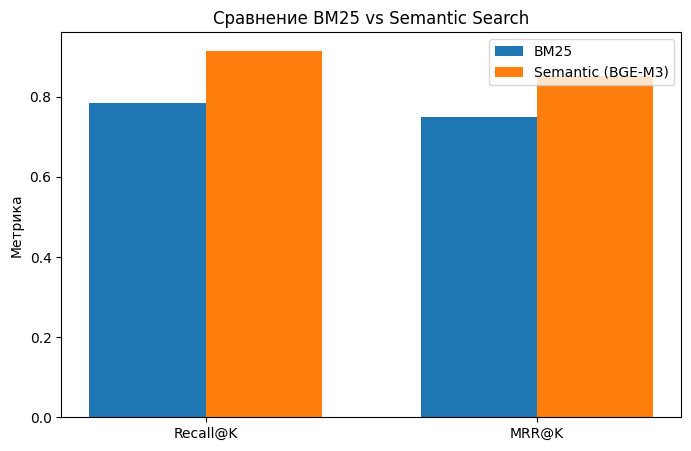

In [7]:
import time
import matplotlib.pyplot as plt

def evaluate_retriever(search_func, queries_data, corpus, k=5):
    recall_hits = 0
    mrr_sum = 0
    start_time = time.time()

    for item in queries_data:
        query = item['question']
        ground_truth = item['ground_truth'].lower()

        # Получаем топ-K doc_ids
        retrieved_ids = search_func(query, k=k)

        hit_rank = None
        for rank, doc_id in enumerate(retrieved_ids):
            doc_text = corpus[doc_id].lower()
            if ground_truth in doc_text:
                hit_rank = rank + 1
                break

        if hit_rank is not None:
            recall_hits += 1
            mrr_sum += 1.0 / hit_rank

    latency = time.time() - start_time

    recall = recall_hits / len(queries_data)
    mrr = mrr_sum / len(queries_data)
    avg_latency_ms = (latency / len(queries_data)) * 1000

    return {"Recall@K": recall, "MRR@K": mrr, "Latency_ms": avg_latency_ms}

# === ВАШ КОД ЗДЕСЬ ===
# 1. Запуск оценки
bm25_metrics = evaluate_retriever(search_bm25, test_queries, corpus, k=5)
semantic_metrics = evaluate_retriever(search_semantic, test_queries, corpus, k=5)

print("BM25:", bm25_metrics)
print("Semantic:", semantic_metrics)

# 2. Визуализация результатов (matplotlib или seaborn)
metrics_names = ['Recall@K', 'MRR@K']
bm25_values = [bm25_metrics['Recall@K'], bm25_metrics['MRR@K']]
semantic_values = [semantic_metrics['Recall@K'], semantic_metrics['MRR@K']]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, bm25_values, width, label='BM25')
plt.bar(x + width/2, semantic_values, width, label='Semantic (BGE-M3)')
plt.xticks(x, metrics_names)
plt.ylabel('Метрика')
plt.title('Сравнение BM25 vs Semantic Search')
plt.legend()
plt.show()
# === КОНЕЦ ВАШЕГО КОДА ===



### Задание 5. RAG с декодером (Qwen3.5-9B) (7 баллов)

Поиск — это только половина RAG. Вторая половина — генерация ответа с помощью декодерной LLM.
Мы будем использовать модель `Qwen/Qwen3.5-9B-Instruct`. Вы можете вызывать ее через API (например, бесплатный OpenRouter) или загрузить локально, если позволяет видеопамять.

**Что нужно сделать:**
1. Реализуйте функцию `generate_answer(query, context_docs)`, которая формирует промпт (инструкция + контексты + вопрос) и вызывает LLM для получения ответа.
2. Напишите обертку `rag_pipeline(query, search_func, k=3)`, которая сначала ищет документы, а затем генерирует ответ.
3. Протестируйте ваш пайплайн на 3-5 любых вопросах (можно придумать свои), используя семантический поиск. Выведите вопрос, найденный контекст и ответ LLM.


In [ ]:
import os
# Если используете OpenRouter API:
from openai import OpenAI
client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key="sk-or-v1-")

# === ВАШ КОД ЗДЕСЬ ===
def generate_answer(query, context_docs):
    context_text = "\n\n".join([corpus[doc_id][:500] for doc_id in context_docs])
    prompt = f"Используй только следующий контекст для ответа на вопрос.\nКонтекст:\n{context_docs}\n\nВопрос: {query}\nОтвет:"
    response = client.chat.completions.create(
            model="qwen/qwen3.5-9b",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=300,
            temperature=0.3
        )
    msg = response.choices[0].message
    return msg.content or msg.reasoning


def rag_pipeline(query, search_func, k=3):
    doc_ids = search_func(query, k=k)
    answer = generate_answer(query, doc_ids)
    return answer, doc_ids


# Тестирование на 3-5 вопросах
test_questions = [
    "В каком году был основан Московский университет?",
    "Кто написал роман Война и мир?",
    "Что такое фотосинтез?"
]

for q in test_questions:
    print(f"\n=== Вопрос: {q} ===")
    answer, doc_ids = rag_pipeline(q, search_semantic)
    print(f"Найденные документы: {doc_ids}")
    print(f"Ответ: {answer}")

# === КОНЕЦ ВАШЕГО КОДА ===




=== Вопрос: В каком году был основан Московский университет? ===
Найденные документы: [2340, 2119, 1413]
Ответ: Thinking Process:

1.  **Analyze the Request:**
    *   Input: A context snippet `[2340, 2119, 1413]` and a question "В каком году был основан Московский университет?" (In what year was Moscow University founded?).
    *   Constraint: "Используй только следующий контекст для ответа на вопрос" (Use *only* the following context to answer the question).
    *   Task: Answer the question based *strictly* on the provided context.

2.  **Analyze the Context:**
    *   Context provided: `[2340, 2119, 1413]`
    *   This looks like a list of numbers, possibly page numbers, timestamps, or some other identifiers. It does *not* contain any text about Moscow University, its founding, or any years associated with it.

3.  **Evaluate the Question vs. Context:**
    *   Question asks for a specific year (founding of Moscow University).
    *   Context provides only three numbers without an

### Задание 6. Оценка стоимости запросов (5 баллов)

В коммерческой разработке важно понимать экономику продукта. Провайдеры API тарифицируют токены (входные и выходные).
Размер входного промпта напрямую зависит от количества передаваемых чанков (найденных документов) и их длины. Длина ответа контролируется системным промптом.

**Что нужно сделать:**
1. Используя библиотеку `tiktoken` (энкодер `cl100k_base` близок к большинству современных LLM), напишите функцию `estimate_cost(query, retrieved_docs, max_output_tokens)`.
2. Предположим тариф: $0.50 за 1M входных токенов и $1.50 за 1M выходных токенов.
3. Посчитайте среднюю стоимость 1000 запросов для трех сценариев:
   - k=1 (передаем 1 документ), короткий ответ (max 50 токенов)
   - k=3 (передаем 3 документа), средний ответ (max 150 токенов)
   - k=5 (передаем 5 документов), развернутый ответ (max 300 токенов)
4. В качестве запроса и документов используйте усредненные длины из вашего тестового набора.


In [16]:
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

# === ВАШ КОД ЗДЕСЬ ===
def estimate_cost(query_text, docs_texts, max_output_tokens):
    context = "\n\n".join(docs_texts)
    prompt = f"Используй только следующий контекст для ответа на вопрос. Если ответа нет в контексте, скажи 'Не могу найти ответ'.\n\nКонтекст:\n{context}\n\nВопрос: {query_text}\nОтвет:"

    input_tokens = len(encoding.encode(prompt))
    output_tokens = max_output_tokens

    input_cost = (input_tokens / 1_000_000) * 0.50
    output_cost = (output_tokens / 1_000_000) * 1.50

    return input_cost + output_cost

# Средние длины
avg_query_len = np.mean([len(encoding.encode(q['question'])) for q in test_queries])
avg_doc_len = np.mean([len(encoding.encode(doc)) for doc in corpus])

print(f"Средняя длина вопроса: {avg_query_len:.0f} токенов")
print(f"Средняя длина документа: {avg_doc_len:.0f} токенов\n")

# 3 сценария
scenarios = [
    (1, 50, "k=1, короткий ответ (50 токенов)"),
    (3, 150, "k=3, средний ответ (150 токенов)"),
    (5, 300, "k=5, развернутый ответ (300 токенов)")
]

print("Стоимость 1000 запросов:")
for k, max_out, desc in scenarios:
    docs = [corpus[0]] * k
    cost_one = estimate_cost(test_queries[0]['question'], docs, max_out)
    cost_1000 = cost_one * 1000
    print(f"  {desc}: ${cost_1000:.4f}")

# === КОНЕЦ ВАШЕГО КОДА ===



Средняя длина вопроса: 29 токенов
Средняя длина документа: 356 токенов

Стоимость 1000 запросов:
  k=1, короткий ответ (50 токенов): $0.2485
  k=3, средний ответ (150 токенов): $0.6725
  k=5, развернутый ответ (300 токенов): $1.1715


---
# Часть 2. Продвинутое ДЗ (50 баллов)

В этой части мы улучшим качество поиска, объединив сильные стороны BM25 и семантики, а также добавим этап переранжирования (Reranking).


### Задание 7. Гибридный поиск (RRF) (10 баллов)

BM25 хорош для точных совпадений (имена, артикулы), а семантика — для понимания смысла. Гибридный поиск объединяет их выдачу.
Один из лучших способов объединения списков разной природы без настройки весов — Reciprocal Rank Fusion (RRF).
Формула RRF: $Score(d) = \sum_{r \in R} \frac{1}{k + rank_r(d)}$, где $rank_r(d)$ — позиция документа в выдаче конкретного ретривера, а $k$ — константа сглаживания (обычно 60).

**Что нужно сделать:**
1. Реализуйте функцию `search_hybrid(query, k=5, rrf_k=60)`.
2. Внутри функции сделайте запрос к `search_bm25` (получите топ-20) и к `search_semantic` (получите топ-20).
3. Примените формулу RRF для подсчета итоговых скоров документов.
4. Отсортируйте документы по убыванию RRF-скора и верните топ-K.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
def search_hybrid(query, k=5, rrf_k=60):
    """
    Выполняет гибридный поиск с использованием RRF.
    """
    # bm25_results = search_bm25(query, k=20)
    # semantic_results = search_semantic(query, k=20)

    # rrf_scores = {}
    # ... логика RRF ...

    pass

# Проверка
# print(search_hybrid(sample_query, k=3))
# === КОНЕЦ ВАШЕГО КОДА ===



### Задание 8. Переранжирование (Cross-Encoder) (12 баллов)

Bi-Encoder (наш BGE-M3) быстр, так как векторы документов предвычисляются. Но он упускает тонкие взаимосвязи между запросом и документом.
Cross-Encoder принимает на вход пару (Запрос, Документ) одновременно и прогоняет их через все слои внимания трансформера. Это медленно, поэтому его применяют только к небольшому топу кандидатов (переранжирование).

Мы будем использовать `BAAI/bge-reranker-v2-m3`.

**Что нужно сделать:**
1. Загрузите модель cross-encoder (через `SentenceTransformer` или `CrossEncoder`).
2. Реализуйте функцию `search_with_reranking(query, k=5, top_n_initial=20)`.
3. Внутри: получите `top_n_initial` кандидатов через `search_hybrid`.
4. Сформируйте пары `(query, doc_text)` для всех кандидатов и передайте их в cross-encoder для получения скоров.
5. Отсортируйте кандидатов по скорам cross-encoder и верните итоговые топ-K.


In [ ]:
from sentence_transformers import CrossEncoder

print("Загрузка модели Reranker...")
reranker = CrossEncoder('BAAI/bge-reranker-v2-m3')

# === ВАШ КОД ЗДЕСЬ ===
def search_with_reranking(query, k=5, top_n_initial=20):
    """
    Двухстадийный поиск: Гибридный (топ-20) -> Reranker (топ-K).
    """
    pass

# Проверка
# print(search_with_reranking(sample_query, k=3))
# === КОНЕЦ ВАШЕГО КОДА ===



### Задание 9. Полный пайплайн с переранжированием и LLM (8 баллов)

Теперь у нас есть мощный поисковый движок. Давайте обновим наш генеративный пайплайн.

**Что нужно сделать:**
1. Создайте функцию `advanced_rag_pipeline(query)`, которая использует `search_with_reranking` (k=3) для поиска контекста и ту же LLM (Qwen3.5-9B) для генерации.
2. Протестируйте на тех же 3-5 вопросах, что и в Задании 5.
3. В комментариях кратко отметьте, изменилось ли качество или детализация ответов.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
def advanced_rag_pipeline(query):
    pass

# Тестирование
# ...
# === КОНЕЦ ВАШЕГО КОДА ===



### Задание 10. Сравнительный анализ всех стратегий и замер скорости (10 баллов)

Пришло время подвести итоги работы поисковых алгоритмов.

**Что нужно сделать:**
1. Запустите `evaluate_retriever` на тестовой выборке (200 вопросов) для всех 4 стратегий:
   - BM25
   - Semantic (BGE-M3)
   - Hybrid (RRF)
   - Hybrid + Reranking
2. Сведите результаты (Recall@5, MRR@5, Latency_ms) в единую таблицу (pandas DataFrame).
3. Постройте два графика:
   - Сравнение метрик качества (Recall и MRR).
   - Сравнение задержки (Latency) для разных методов.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
# 1. Сбор метрик
# hybrid_metrics = evaluate_retriever(search_hybrid, test_queries, corpus, k=5)
# rerank_metrics = evaluate_retriever(search_with_reranking, test_queries, corpus, k=5)

# 2. Создание DataFrame и вывод таблицы

# 3. Визуализация (качество и скорость)

# === КОНЕЦ ВАШЕГО КОДА ===



### Задание 11. Расширенная оценка стоимости запросов (5 баллов)

В продвинутом пайплайне мы используем переранжирование, что увеличивает время ответа, но как это влияет на стоимость LLM?
Само переранжирование (cross-encoder) работает локально и бесплатно. Значит, стоимость API LLM зависит только от финального K (количества документов, передаваемых в промпт).

**Что нужно сделать:**
1. Постройте график зависимости стоимости 1000 запросов от параметра K (от 1 до 10) при фиксированной длине ответа (например, 150 токенов).
2. Используйте функцию `estimate_cost` из Задания 6. Усредните длину документа по корпусу для расчетов.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===



### Задание 12. Итоговые выводы (5 баллов)

Поздравляем с завершением практической части! Теперь проанализируйте полученные результаты.

**Что нужно сделать:**
Напишите развернутый вывод (3-4 абзаца) в markdown-ячейке ниже. Ответьте на вопросы:
1. Какой метод поиска показал лучшее качество на данном датасете и почему?
2. Оправдано ли использование тяжелого Reranker-а с точки зрения баланса качество/скорость (latency)? В каких бизнес-кейсах вы бы его рекомендовали, а в каких — отключили?
3. Как размер контекста (параметр K) влияет на баланс между качеством ответов LLM и стоимостью эксплуатации системы? Какое значение K вы бы выбрали для "ВикиПомощника"?

---
*Пишите ваши выводы здесь...*


## Критерии оценки
- **Работоспособность кода:** Код выполняется без ошибок, пайплайны поиска и генерации функционируют корректно.
- **Корректность алгоритмов:** Верная реализация RRF, правильное использование FAISS и Cross-Encoder.
- **Качество визуализации:** Графики читаемы, имеют оси и легенду, таблица метрик наглядна.
- **Глубина анализа:** Выводы в задании 12 логичны, опираются на полученные цифры и бизнес-контекст.
- **Оформление:** Код структурирован, присутствуют комментарии на русском языке, соблюден академический стиль.
